Quartile and IQR Summary:


,Q1,Median,Q3,IQR
fixed acidity,7.100,7.900,9.100,2.000
volatile acidity,0.392,0.520,0.640,0.248
citric acid,0.090,0.250,0.420,0.330
residual sugar,1.900,2.200,2.600,0.700
chlorides,0.070,0.079,0.090,0.020
free sulfur dioxide,7.000,13.000,21.000,14.000
total sulfur dioxide,21.000,37.000,61.000,40.000
density,0.996,0.997,0.998,0.002
pH,3.205,3.310,3.400,0.195
sulphates,0.550,0.620,0.730,0.180


Outlier Boundaries:


,Lower Bound,Upper Bound
fixed acidity,4.100,12.100
volatile acidity,0.021,1.011
citric acid,-0.405,0.915
residual sugar,0.850,3.650
chlorides,0.040,0.120
free sulfur dioxide,-14.000,42.000
total sulfur dioxide,-39.000,121.000
density,0.992,1.001
pH,2.913,3.692
sulphates,0.280,1.000


Outlier Summary:


,Outlier Count,Outlier Percentage
fixed acidity,44,3.85
volatile acidity,14,1.22
citric acid,1,0.09
residual sugar,110,9.62
chlorides,77,6.74
free sulfur dioxide,18,1.57
total sulfur dioxide,40,3.50
density,36,3.15
pH,20,1.75
sulphates,43,3.76


Outliers in residual sugar:


,Id,residual sugar,quality
311,442,3.70,7
804,1138,3.70,5
1106,1552,3.70,6
1048,1471,3.75,5
944,1331,3.80,5
...,...,...,...
231,325,11.00,6
1051,1474,13.80,5
1053,1476,13.80,5
1022,1434,15.40,6


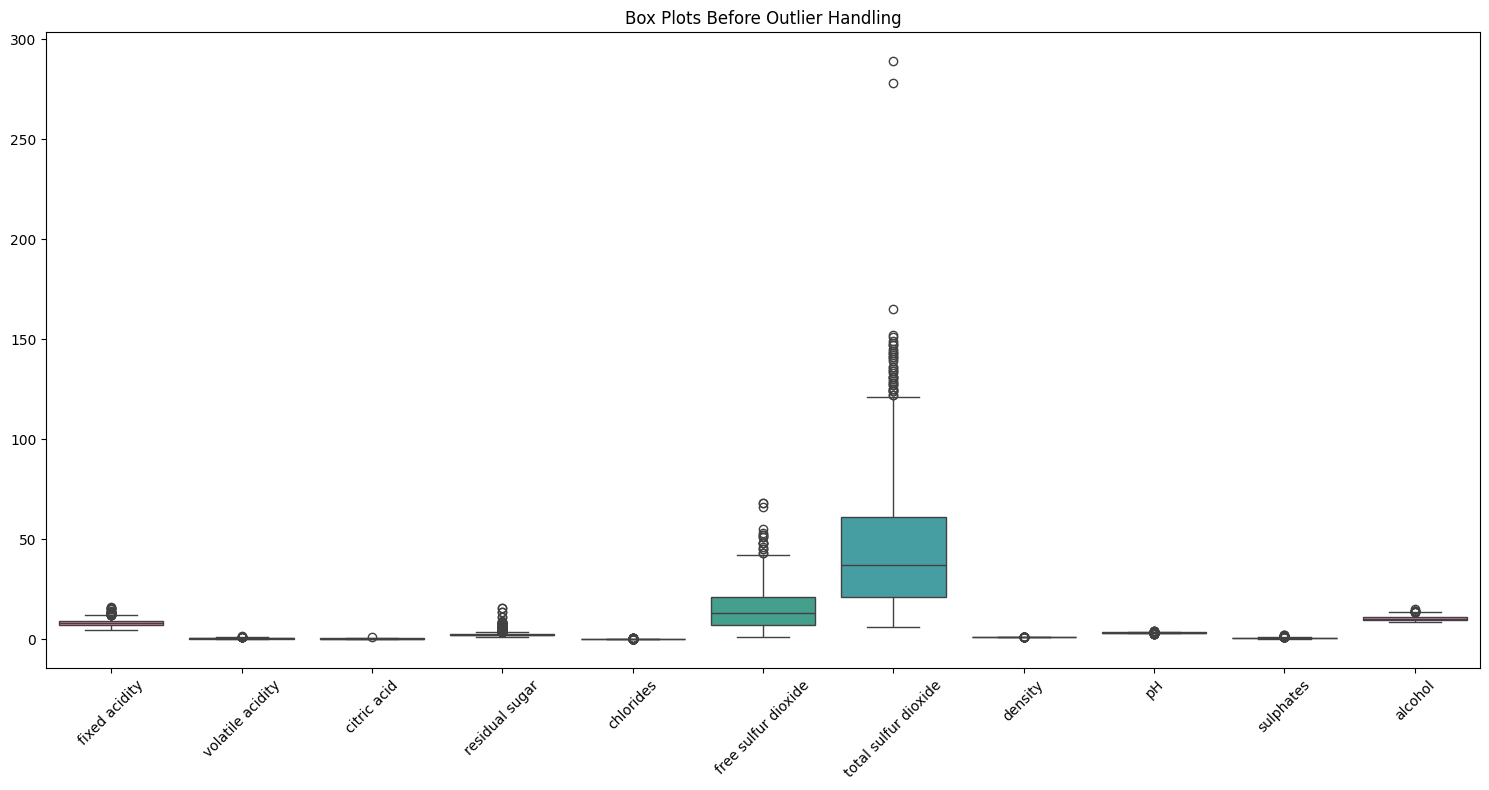

Original rows: 1143
Rows after removing IQR outliers: 848
Rows removed: 295
Standard Deviation Comparison:


,Before,After,Change
fixed acidity,1.748,1.405,-0.342
volatile acidity,0.180,0.165,-0.014
citric acid,0.197,0.180,-0.017
residual sugar,1.356,0.447,-0.909
chlorides,0.047,0.014,-0.033
free sulfur dioxide,10.250,8.720,-1.530
total sulfur dioxide,32.782,25.715,-7.067
density,0.002,0.002,-0.000
pH,0.157,0.136,-0.021
sulphates,0.170,0.114,-0.056


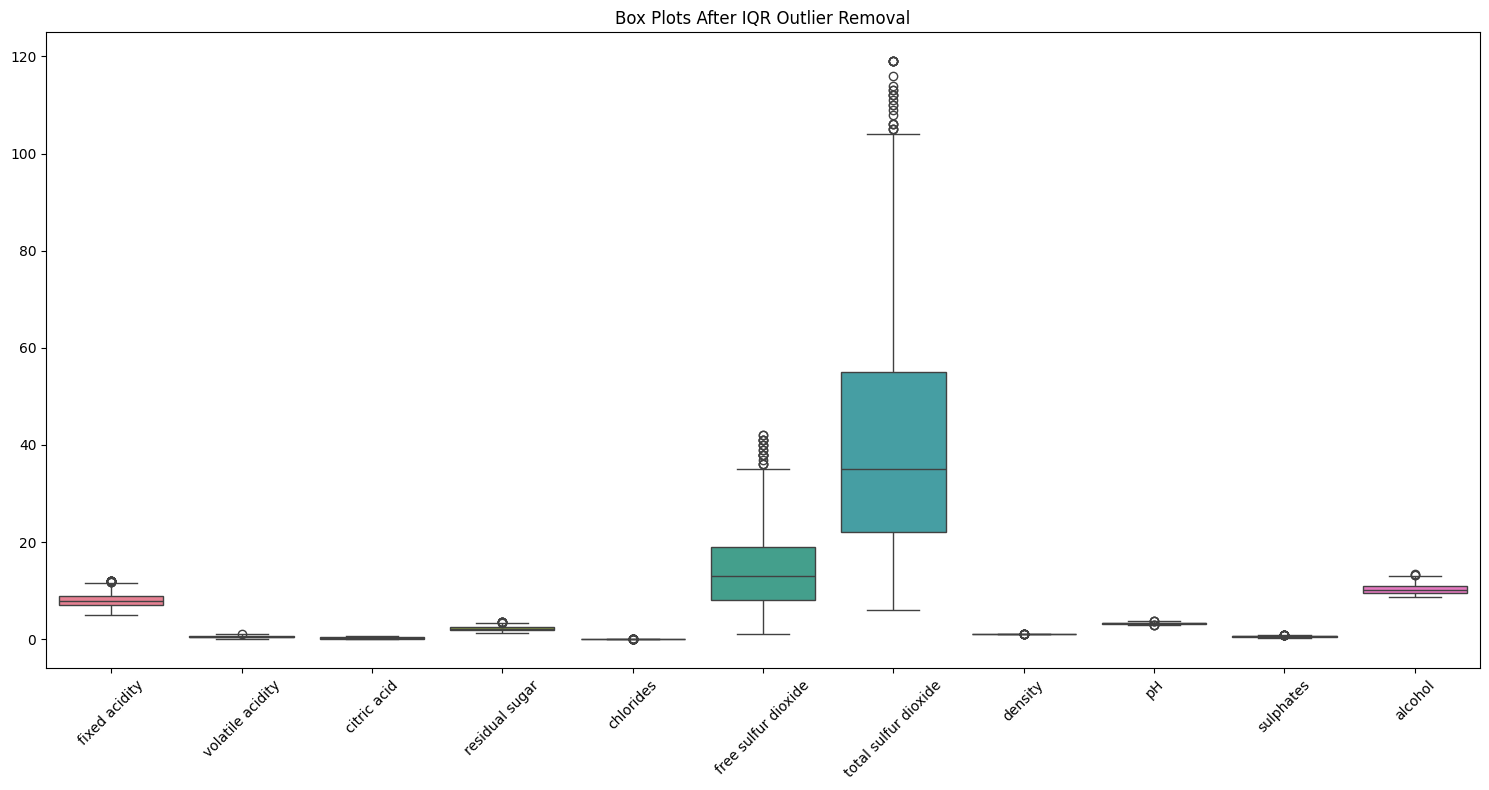


Dataset Size Comparison:
Before: (1143, 13)
After : (848, 13)


In [1]:
# ============================================================
# 04 - IQR and Outlier Analysis
# Wine Quality Dataset
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/WineQT.csv")

# ============================================================
# 1. Select Numerical Features
# ============================================================

features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

# ============================================================
# 2. Calculate Quartiles and IQR
# ============================================================

q1 = df[features].quantile(0.25)
q2 = df[features].quantile(0.50)
q3 = df[features].quantile(0.75)

iqr = q3 - q1

iqr_summary = pd.DataFrame({
    "Q1": q1,
    "Median": q2,
    "Q3": q3,
    "IQR": iqr
})

print("Quartile and IQR Summary:")
display(iqr_summary.round(3))

# ============================================================
# 3. Calculate Outlier Boundaries
# ============================================================

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

bounds = pd.DataFrame({
    "Lower Bound": lower_bound,
    "Upper Bound": upper_bound
})

print("Outlier Boundaries:")
display(bounds.round(3))

# ============================================================
# 4. Count Outliers
# ============================================================

outlier_counts = {}

for column in features:
    outliers = df[
        (df[column] < lower_bound[column]) |
        (df[column] > upper_bound[column])
    ]

    outlier_counts[column] = len(outliers)

outlier_summary = pd.DataFrame.from_dict(
    outlier_counts,
    orient="index",
    columns=["Outlier Count"]
)

outlier_summary["Outlier Percentage"] = (
    outlier_summary["Outlier Count"] / len(df) * 100
)

print("Outlier Summary:")
display(outlier_summary.round(2))

# ============================================================
# 5. Identify Outlier Rows
# ============================================================

column = "residual sugar"

outliers = df[
    (df[column] < lower_bound[column]) |
    (df[column] > upper_bound[column])
]

print(f"Outliers in {column}:")
display(
    outliers[
        ["Id", column, "quality"]
    ].sort_values(column)
)

# ============================================================
# 6. Box Plot Before Outlier Removal
# ============================================================

plt.figure(figsize=(15, 8))

sns.boxplot(data=df[features])

plt.xticks(rotation=45)
plt.title("Box Plots Before Outlier Handling")
plt.tight_layout()
plt.show()

# ============================================================
# 7. IQR Outlier Removal
# ============================================================

outlier_mask = (
    (df[features] < lower_bound) |
    (df[features] > upper_bound)
).any(axis=1)

df_clean = df[~outlier_mask].copy()

print("Original rows:", len(df))
print("Rows after removing IQR outliers:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

# ============================================================
# 8. Compare Before and After
# ============================================================

comparison = pd.DataFrame({
    "Before": df[features].std(),
    "After": df_clean[features].std()
})

comparison["Change"] = comparison["After"] - comparison["Before"]

print("Standard Deviation Comparison:")
display(comparison.round(3))

# ============================================================
# 9. Box Plot After Outlier Removal
# ============================================================

plt.figure(figsize=(15, 8))

sns.boxplot(data=df_clean[features])

plt.xticks(rotation=45)
plt.title("Box Plots After IQR Outlier Removal")
plt.tight_layout()
plt.show()

# ============================================================
# 10. Compare Dataset Size
# ============================================================

print("\nDataset Size Comparison:")
print("Before:", df.shape)
print("After :", df_clean.shape)